# خصائص الاطارات:

1. ** الاستدارة**

2. ** القطر المكافئ**

3. ** القناع ونقاط البكسلات **

4. ** القيم العظمى والصغرى واماكنها**

5. ** اللون الوسطي او الشدة الوسطية**

6. ** النقاط القصوى **




#  الاطارات : توابع اخرى:

## الهدف:

* تعلم عيوب التحدب وكيفية ايجادهم 

* ايجاد المسافة الاقصر من نقطة لمضلع

* مقارنة الاشكال المختلفة

##  النظرية والكود:
** عيوب التحدب ** هي اي فروقات لسطح الجسم الحقيقي عن السطح المحدب الاصغر المحيط,
وهناك  تابع جاهز يقوم بايجادها وتتم مناداته كالاتي 
<p style="text-align:center;"dir="ltr">

<strong>hull = cv2.convexHull(cnt,returnPoints = False)</strong>
<br>

<strong>defects = cv2.convexityDefects(cnt,hull)</strong>
</p>

ملاحظة : عليك تمرير المتغير الثاني للتابع الاول 
ك
`False`
وهذا يعيد مصفوفة حيث كل سطر يتضمن هذه القيم :
*نقطة البداية - نقطة النهاية - النقطة الابعد - المسافة المقربة للنقطة الابعد*

وسنكتب برنامج توضيحي يقوم برسم مستقيم حول اول نقطتين ودائرة حول النقطة الثالثة
,ولكن تذكر تمثل تلك النقاط بشكل دلائل للاحداثيات بمصفوفة الاطار بالدخل

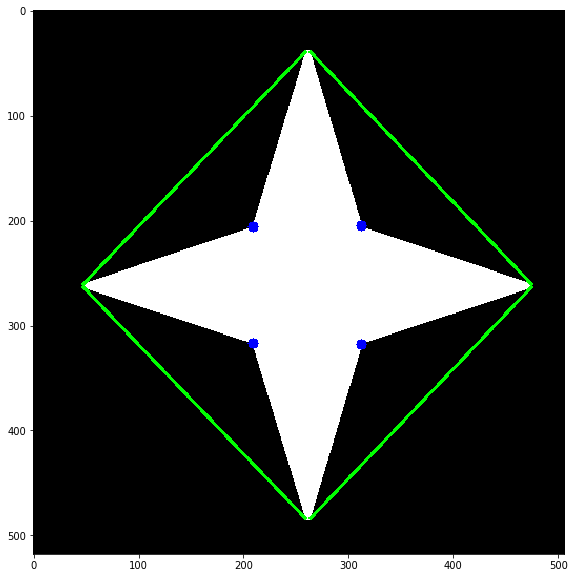

In [1]:
%matplotlib inline
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('star.png')
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(img_gray, 127, 255,0)
contours,hierarchy = cv2.findContours(thresh,2,1)
cnt = contours[0]

hull = cv2.convexHull(cnt,returnPoints = False)
defects = cv2.convexityDefects(cnt,hull)

for i in range(defects.shape[0]):
    s,e,f,d = defects[i,0]
    start = tuple(cnt[s][0])
    end = tuple(cnt[e][0])
    far = tuple(cnt[f][0])
    # d is the desitance
    cv2.line(img,start,end,[0,255,0],2)
    cv2.circle(img,far,5,[0,0,255],-1)

plt.figure(figsize=[10,10])
plt.imshow(img , cmap = 'gray')
plt.show()

** اختبار النقطة - المضلع ** وهذا التابع يفيد في معرفة هل النقطة داخل ام خارج الشكل ام على المحيط 
بالاضافة لمعرفة المسافة عنه , مثلاً للبكسل `50 ,50` التالي:
<p style="text-align:center;"dir="ltr">
dist = cv2.pointPolygonTest(cnt,(50,50),True)
</p>
والمتغير البولاني الاخير هو للتخيير هل يحسب المسافة عن المحيط ام يعرف المنطقة فقط , الخيار الابسط يوفر بالسرعة حوالي ضعف ل 3 اضعاف

###  مقارنة الاشكال :

تأتي المكتبة مع نابع جاهز وهو
**cv2.matchShapes**
حيث 
يقوم بمقارنة تشابه محيطين ويعطي قيمة بارامترية , لمدى التشابه , كلما كانت اقل كان التشابه اكبر , وهذا يتم انطلاقاً من حسابات العزوم. كما ان هناك طرقاً مختلفة للحساب تم شرحها في التوثيق

مثلاً بمقارنة الصورة بنفسها ينبغي ان نحصل على 
`0.0`

In [3]:
img1 = cv2.imread('star.png',0)
img2 = cv2.imread('star.png',0)

ret, thresh = cv2.threshold(img1, 127, 255,0)
ret, thresh2 = cv2.threshold(img2, 127, 255,0)
contours,hierarchy = cv2.findContours(thresh,2,1)
cnt1 = contours[0]
contours,hierarchy = cv2.findContours(thresh2,2,1)
cnt2 = contours[0]

ret = cv2.matchShapes(cnt1,cnt2,1,0.0)
print ret

0.0


حيث نلاحظ التشابه كامل , وتجدر الملاحظة ان التدوير لايؤثر على المطابقة بسبب ان القيم المحسوبة هي عزوم
تلك العزوم تدعى 
** Hu-Moments **
وهي لا تتأثر بالتدوير او الازاحة وعددها سبع عزوم , ويمكن ايجاد هذه القيم عبر التابع التالي 


In [9]:
a = cv2.HuMoments(contours)
print a ,'\n', len(a)

[[ 0.]
 [ 0.]
 [ 0.]
 [ 0.]
 [ 0.]
 [ 0.]
 [ 0.]] 
7


أما بشأن شكلين مختلفين كالتالي:

0.394374510915


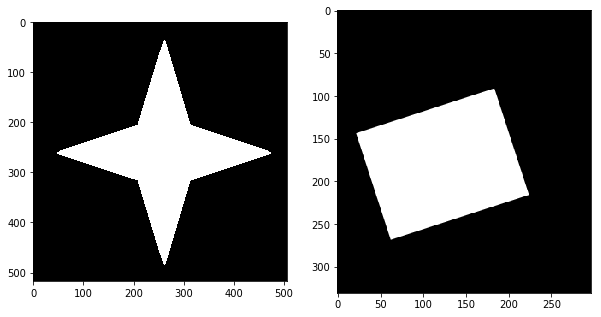

In [10]:
img1 = cv2.imread('star.png',0)
img2 = cv2.imread('box2.png',0)

ret, thresh = cv2.threshold(img1, 127, 255,0)
ret, thresh2 = cv2.threshold(img2, 127, 255,0)
contours,hierarchy = cv2.findContours(thresh,2,1)
cnt1 = contours[0]
contours,hierarchy = cv2.findContours(thresh2,2,1)
cnt2 = contours[0]

ret = cv2.matchShapes(cnt1,cnt2,1,0.0)
print ret

plt.figure(figsize=[10,10])
plt.subplot(121)
plt.imshow(img1,cmap = 'gray')

plt.subplot(122)
plt.imshow(img2,cmap = 'gray')
plt.show()

لاحظ الاختلاف لقيمة البارامتر عن الصفر

##  تمارين:

- *اولا* -  بالتوثيق الاصلي , يوجد صورة تمثل تأثيرالتابع 
** cv2.pointPolygonTest ** 
حيث تزداد قيمة شدة اللون حسب القيمة الناتجة عنه , والحواف صفرية ,
السؤال , هل يمكنك كتابة برنامج لتوليد هكذا تمثيل لاي اطار ..

- *ثانياً * - قارن صورا لارقام او احرف باستخدام التابع
** cv2.matchShapes** 
وهذا سيكون خطوة بسيطة باتجاه ال
OCR